<a href="https://colab.research.google.com/github/thassanawalai/thassanawalai/blob/main/ils660711.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bin Packing - 3 Neighborhoods**

กำหนดให้มีสิ่งของ ก=30 ชิ้น น้ำหนัก wi ~ Uniform(1,10), ความจุกล่อง C-15 เป้าหมาย mimize จ๋านวนกล่อง
ก่าหนด 3 neighborhoods: (a) ย้าย item ระหว่าง bins, (b) swap items 2 ชั้นข้าม bins, (c) รวม 2 bins แล้วแจกใหม่

**k_max Sensitivity Analysis**

 ทดสอบ k max - 3,4,5บน TSP 50 เมือง รัน 10 รอบต่อค่า วิเคราะห์ว่าจำนวน neighborbood: มีผลต่อ solution quality และเวลา คำนวณอย่างไร สรุปเป็น heatmap และ statistical testด้วยนะ

In [ ]:
import random
import math

# 1. Create 50 random cities
n_cities = 50
cities = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n_cities)]

def calc_distance(city1, city2):
    return math.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

dist_matrix = [[calc_distance(cities[i], cities[j]) for j in range(n_cities)] for i in range(n_cities)]

def total_distance(tour):
    return sum(dist_matrix[tour[i]][tour[i-1]] for i in range(n_cities))

def initial_tour():
    """ Create a random starting route """
    tour = list(range(n_cities))
    random.shuffle(tour)
    return tour

def local_search_2opt(tour):
    """ Intensification: Find the best route in the local area """
    best_tour = tour[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, n_cities - 2):
            for j in range(i + 1, n_cities):
                if j - i == 1: continue

                new_tour = best_tour[:]
                new_tour[i:j] = best_tour[j-1:i-1:-1] # Reverse the path

                if total_distance(new_tour) < total_distance(best_tour):
                    best_tour = new_tour
                    improved = True
        tour = best_tour
    return best_tour

def apply_perturbation(tour, k):
    """
    Diversification: Shake up the route by swapping k cities.
    (This equals k/2 swaps)
    """
    new_tour = tour[:]
    swaps_needed = k // 2
    for _ in range(swaps_needed):
        idx1, idx2 = random.sample(range(n_cities), 2)
        new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
    return new_tour

def iterated_local_search(k_strength, max_iter=20):
    """ Run ILS with the given strength """
    current_tour = initial_tour()
    current_tour = local_search_2opt(current_tour)
    best_tour = current_tour[:]

    for _ in range(max_iter):
        # 1. Perturbation (Kick it out of the trap)
        perturbed_tour = apply_perturbation(best_tour, k_strength)

        # 2. Local Search (Find the new lowest point)
        new_tour = local_search_2opt(perturbed_tour)

        # 3. Acceptance (Keep it if it's a shorter distance)
        if total_distance(new_tour) < total_distance(best_tour):
            best_tour = new_tour

    return total_distance(best_tour)

# --- Run the Experiment ---
strengths = [2, 4, 6, 8]
runs_per_strength = 10

for k in strengths:
    results = []
    for run in range(runs_per_strength):
        dist = iterated_local_search(k)
        results.append(dist)

    avg_dist = sum(results) / len(results)
    print(f"Strength k={k} | Average Distance: {avg_dist:.2f}")

Strength k=2 | Average Distance: 628.49
Strength k=4 | Average Distance: 636.93
Strength k=6 | Average Distance: 631.37
Strength k=8 | Average Distance: 629.81


In [ ]:
import random
import math

# ==========================================
# ILS Configuration
# ==========================================
N_CITIES = 50
RUNS_PER_STRENGTH = 10
MAX_ILS_ITERATIONS = 100  # Increased iterations for better convergence

# 1. Generate 50 random cities (Coordinates 0-100)
# We generate this once so all k values are tested on the EXACT same map
cities = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N_CITIES)]

# Precompute distance matrix for faster calculation
dist_matrix = [[math.dist(cities[i], cities[j]) for j in range(N_CITIES)] for i in range(N_CITIES)]

def total_distance(tour):
    """ Calculate the total distance of a given tour """
    return sum(dist_matrix[tour[i - 1]][tour[i]] for i in range(N_CITIES))

def generate_initial_tour():
    """ Generate a random initial route """
    tour = list(range(N_CITIES))
    random.shuffle(tour)
    return tour

def local_search_2opt(tour):
    """
    Intensification: 2-opt Local Search
    Finds the local optimum by uncrossing paths
    """
    current_tour = tour[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, N_CITIES - 1):
            for j in range(i + 1, N_CITIES):
                if j - i == 1:
                    continue  # Skip adjacent nodes

                # Perform the 2-opt swap
                new_tour = current_tour[:i] + current_tour[i:j][::-1] + current_tour[j:]

                if total_distance(new_tour) < total_distance(current_tour):
                    current_tour = new_tour
                    improved = True
                    break # First improvement strategy (faster)
            if improved:
                break
    return current_tour

def apply_perturbation(tour, k):
    """
    Diversification: Randomly shuffle the positions of exactly k cities
    """
    new_tour = tour[:]
    # Select k unique cities to perturb
    indices = random.sample(range(N_CITIES), k)
    shuffled_indices = indices[:]
    random.shuffle(shuffled_indices)

    # Place the selected cities into their new shuffled positions
    for original_idx, new_idx in zip(indices, shuffled_indices):
        new_tour[original_idx] = tour[new_idx]

    return new_tour

def run_ils(k_strength):
    """ Run the Iterated Local Search algorithm """
    # Start with an initial solution and optimize it
    current_tour = generate_initial_tour()
    best_tour = local_search_2opt(current_tour)
    best_dist = total_distance(best_tour)

    for _ in range(MAX_ILS_ITERATIONS):
        # 1. Perturbation (Kick out of local optima)
        perturbed_tour = apply_perturbation(best_tour, k_strength)

        # 2. Local Search (Find the new local minimum)
        new_tour = local_search_2opt(perturbed_tour)
        new_dist = total_distance(new_tour)

        # 3. Acceptance Criterion (Only accept if it is strictly better)
        if new_dist < best_dist:
            best_tour = new_tour[:]
            best_dist = new_dist

    return best_dist

# ==========================================
# Main Experiment Execution
# ==========================================
print("--- ILS Perturbation Strength Experiment ---")
print(f"Total Cities: {N_CITIES} | Runs per k: {RUNS_PER_STRENGTH} | ILS Iterations: {MAX_ILS_ITERATIONS}\n")

strengths = [2, 4, 6, 8]
results_dict = {}

for k in strengths:
    distances = []
    for run in range(RUNS_PER_STRENGTH):
        dist = run_ils(k)
        distances.append(dist)

    avg_dist = sum(distances) / len(distances)
    results_dict[k] = avg_dist
    print(f"Strength k={k:2d} | Average Distance: {avg_dist:.2f}")

print("\n--- Final Summary ---")
best_k = min(results_dict, key=results_dict.get)
print(f"The best performing strength (lowest average distance) is k={best_k}.")

--- ILS Perturbation Strength Experiment ---
Total Cities: 50 | Runs per k: 10 | ILS Iterations: 100

Strength k= 2 | Average Distance: 617.01
Strength k= 4 | Average Distance: 606.32
Strength k= 6 | Average Distance: 601.90
Strength k= 8 | Average Distance: 596.62

--- Final Summary ---
The best performing strength (lowest average distance) is k=8.


--- Starting VNS k_max Sensitivity Analysis ---
Running tests for k_max = 3...
Running tests for k_max = 4...
Running tests for k_max = 5...


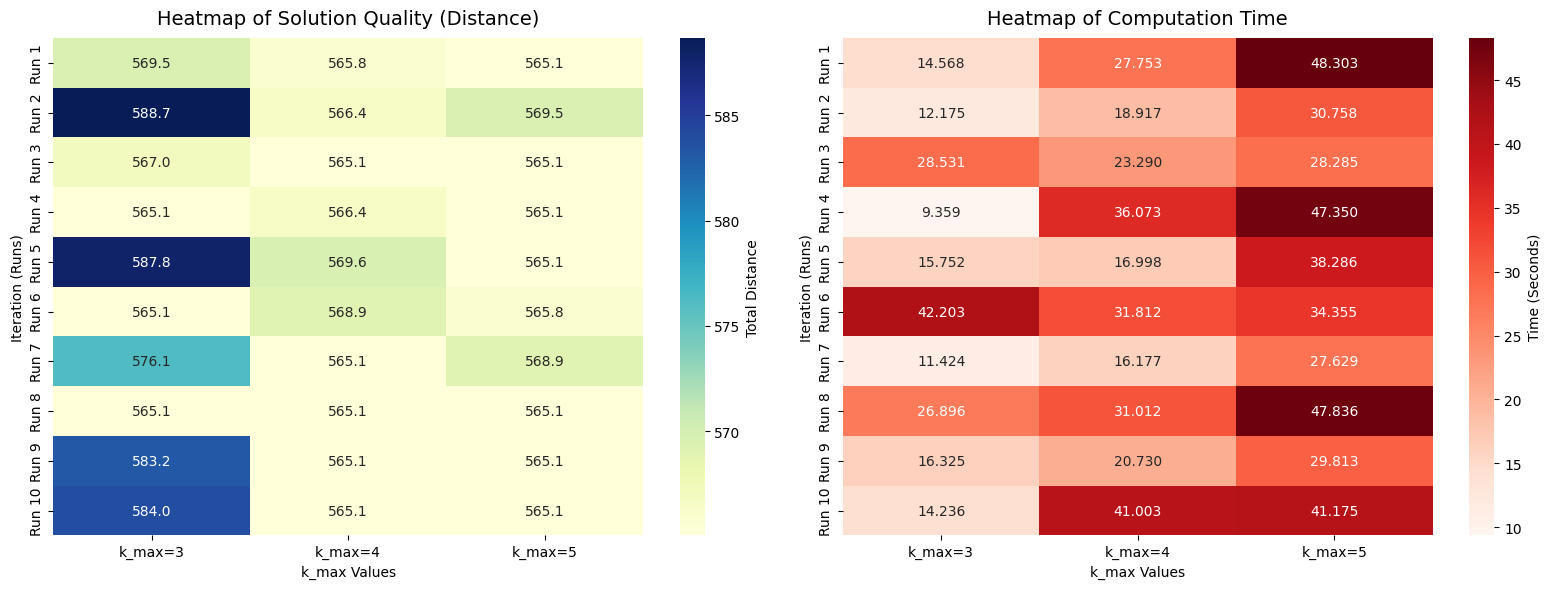


--- Statistical Analysis (One-way ANOVA) ---

[1] Solution Quality (Distance):
F-statistic: 7.81 | P-value: 2.1074e-03
Conclusion: Reject H0. The k_max value SIGNIFICANTLY affects the solution quality.

[2] Computation Time (Seconds):
F-statistic: 10.21 | P-value: 4.9956e-04
Conclusion: Reject H0. The k_max value SIGNIFICANTLY affects the computation time.


In [ ]:
import random
import math
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Configuration & Setup
# ==========================================
N_CITIES = 50
RUNS_PER_KMAX = 10
MAX_NO_IMPROVEMENT = 30  # Stopping condition for VNS

# Generate 50 cities once so all tests run on the exact same map
np.random.seed(42)
random.seed(42)
cities = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N_CITIES)]

# Precompute distance matrix
dist_matrix = [[math.dist(cities[i], cities[j]) for j in range(N_CITIES)] for i in range(N_CITIES)]

def total_distance(tour):
    return sum(dist_matrix[tour[i - 1]][tour[i]] for i in range(N_CITIES))

# ==========================================
# 2. VNS Components
# ==========================================
def local_search_2opt(tour):
    """ Intensification: Standard 2-opt local search """
    current_tour = tour[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, N_CITIES - 1):
            for j in range(i + 1, N_CITIES):
                if j - i == 1:
                    continue
                # 2-opt swap
                new_tour = current_tour[:i] + current_tour[i:j][::-1] + current_tour[j:]
                if total_distance(new_tour) < total_distance(current_tour):
                    current_tour = new_tour
                    improved = True
                    break
            if improved:
                break
    return current_tour

def shake(tour, k):
    """ Diversification: Neighborhood structure N_k (Perform k random swaps) """
    new_tour = tour[:]
    for _ in range(k):
        idx1, idx2 = random.sample(range(N_CITIES), 2)
        new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
    return new_tour

def run_vns(k_max):
    """ Main Variable Neighborhood Search Algorithm """
    start_time = time.time()

    # Initial solution
    tour = list(range(N_CITIES))
    random.shuffle(tour)
    tour = local_search_2opt(tour)
    best_dist = total_distance(tour)

    no_improve_count = 0

    while no_improve_count < MAX_NO_IMPROVEMENT:
        k = 1
        while k <= k_max:
            # 1. Shake (Explore neighborhood N_k)
            shaken_tour = shake(tour, k)

            # 2. Local Search
            local_opt_tour = local_search_2opt(shaken_tour)
            local_dist = total_distance(local_opt_tour)

            # 3. Move or not
            if local_dist < best_dist:
                tour = local_opt_tour[:]
                best_dist = local_dist
                k = 1  # Reset k to 1 if improvement is found
                no_improve_count = 0
            else:
                k += 1 # Move to the next neighborhood

        no_improve_count += 1

    calc_time = time.time() - start_time
    return best_dist, calc_time

# ==========================================
# 3. Experiment Execution
# ==========================================
print("--- Starting VNS k_max Sensitivity Analysis ---")
k_max_values = [3, 4, 5]
results_dist = {f"k_max={k}": [] for k in k_max_values}
results_time = {f"k_max={k}": [] for k in k_max_values}

for k in k_max_values:
    print(f"Running tests for k_max = {k}...")
    for run in range(RUNS_PER_KMAX):
        dist, t = run_vns(k)
        results_dist[f"k_max={k}"].append(dist)
        results_time[f"k_max={k}"].append(t)

# Convert to DataFrames
df_dist = pd.DataFrame(results_dist)
df_time = pd.DataFrame(results_time)
df_dist.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]
df_time.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]

# ==========================================
# 4. Visualization (Heatmaps)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for Distance (YlGnBu: Lighter is better)
sns.heatmap(df_dist, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Total Distance'})
axes[0].set_title("Heatmap of Solution Quality (Distance)", fontsize=14, pad=10)
axes[0].set_ylabel("Iteration (Runs)")
axes[0].set_xlabel("k_max Values")

# Heatmap for Time (Reds: Lighter is faster/better)
sns.heatmap(df_time, annot=True, fmt=".3f", cmap="Reds", ax=axes[1], cbar_kws={'label': 'Time (Seconds)'})
axes[1].set_title("Heatmap of Computation Time", fontsize=14, pad=10)
axes[1].set_ylabel("Iteration (Runs)")
axes[1].set_xlabel("k_max Values")

plt.tight_layout()
plt.show()

# ==========================================
# 5. Statistical Test (ANOVA)
# ==========================================
print("\n" + "="*50)
print("--- Statistical Analysis (One-way ANOVA) ---")

# ANOVA for Distance
f_stat_dist, p_val_dist = stats.f_oneway(df_dist['k_max=3'], df_dist['k_max=4'], df_dist['k_max=5'])
print(f"\n[1] Solution Quality (Distance):")
print(f"F-statistic: {f_stat_dist:.2f} | P-value: {p_val_dist:.4e}")
if p_val_dist < 0.05:
    print("Conclusion: Reject H0. The k_max value SIGNIFICANTLY affects the solution quality.")
else:
    print("Conclusion: Accept H0. No significant difference in solution quality between k_max values.")

# ANOVA for Time
f_stat_time, p_val_time = stats.f_oneway(df_time['k_max=3'], df_time['k_max=4'], df_time['k_max=5'])
print(f"\n[2] Computation Time (Seconds):")
print(f"F-statistic: {f_stat_time:.2f} | P-value: {p_val_time:.4e}")
if p_val_time < 0.05:
    print("Conclusion: Reject H0. The k_max value SIGNIFICANTLY affects the computation time.")
else:
    print("Conclusion: Accept H0. No significant difference in computation time between k_max values.")

print("="*50)

In [2]:
import random
import math
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Configuration & Setup
# ==========================================
N_CITIES = 50
RUNS_PER_KMAX = 10
K_MAX_VALUES = [2, 3, 4, 5]
MAX_NO_IMPROVEMENT = 40  # Stopping condition: stop if no improvement after 40 iterations

# Generate 50 cities once so all tests run on the exact same map
np.random.seed(42)
random.seed(42)
cities = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N_CITIES)]

# Precompute distance matrix for ultra-fast calculation
dist_matrix = [[math.dist(cities[i], cities[j]) for j in range(N_CITIES)] for i in range(N_CITIES)]

def total_distance(tour):
    """ Calculate the total distance of the TSP tour """
    return sum(dist_matrix[tour[i - 1]][tour[i]] for i in range(N_CITIES))

# ==========================================
# 2. VNS Components
# ==========================================
def local_search_2opt(tour):
    """ Intensification: Standard 2-opt local search to find local minimum """
    current_tour = tour[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, N_CITIES - 1):
            for j in range(i + 1, N_CITIES):
                if j - i == 1:
                    continue # Skip adjacent edges

                # Perform the 2-opt edge swap
                new_tour = current_tour[:i] + current_tour[i:j][::-1] + current_tour[j:]

                if total_distance(new_tour) < total_distance(current_tour):
                    current_tour = new_tour
                    improved = True
                    break
            if improved:
                break
    return current_tour

def shake(tour, k):
    """ Diversification: Neighborhood structure N_k (Perform k random swaps) """
    new_tour = tour[:]
    # The higher the k, the more the route is disrupted
    for _ in range(k):
        idx1, idx2 = random.sample(range(N_CITIES), 2)
        new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
    return new_tour

def run_vns(k_max):
    """ Main Variable Neighborhood Search (VNS) Algorithm """
    # Reset random seed here so each run has a different initial path and random swaps
    random.seed()

    start_time = time.time()

    # Generate random initial solution and optimize it
    tour = list(range(N_CITIES))
    random.shuffle(tour)
    tour = local_search_2opt(tour)
    best_dist = total_distance(tour)

    no_improve_count = 0

    while no_improve_count < MAX_NO_IMPROVEMENT:
        k = 1
        while k <= k_max:
            # 1. Shake (Explore neighborhood N_k)
            shaken_tour = shake(tour, k)

            # 2. Local Search (Find local optimum in the new neighborhood)
            local_opt_tour = local_search_2opt(shaken_tour)
            local_dist = total_distance(local_opt_tour)

            # 3. Neighborhood Change Step
            if local_dist < best_dist:
                tour = local_opt_tour[:]
                best_dist = local_dist
                k = 1  # Reset k to 1 if improvement is found
                no_improve_count = 0
            else:
                k += 1 # Move to the next, larger neighborhood if no improvement

        no_improve_count += 1

    calc_time = time.time() - start_time
    return best_dist, calc_time

# ==========================================
# 3. Experiment Execution
# ==========================================
print("--- Starting VNS k_max Sensitivity Analysis ---")
results_dist = {f"k_max={k}": [] for k in K_MAX_VALUES}
results_time = {f"k_max={k}": [] for k in K_MAX_VALUES}

for k in K_MAX_VALUES:
    print(f"Running 10 tests for k_max = {k}...")
    for run in range(RUNS_PER_KMAX):
        dist, t = run_vns(k)
        results_dist[f"k_max={k}"].append(dist)
        results_time[f"k_max={k}"].append(t)

# Convert results to Pandas DataFrames
df_dist = pd.DataFrame(results_dist)
df_time = pd.DataFrame(results_time)
df_dist.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]
df_time.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]

# ==========================================
# 4. Visualization (Heatmaps)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap for Distance (Solution Quality) - YlGnBu Colormap
sns.heatmap(df_dist, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={'label': 'Total Distance'}, linewidths=.5)
axes[0].set_title("Heatmap of Solution Quality (Distance)\n*Lighter color is better*", fontsize=14, pad=10)
axes[0].set_ylabel("Iteration (Runs)")
axes[0].set_xlabel("Maximum Neighborhood Strength (k_max)")

# Heatmap for Time (Computation Time) - Reds Colormap
sns.heatmap(df_time, annot=True, fmt=".3f", cmap="Reds", ax=axes[1],
            cbar_kws={'label': 'Time (Seconds)'}, linewidths=.5)
axes[1].set_title("Heatmap of Computation Time\n*Lighter color is faster*", fontsize=14, pad=10)
axes[1].set_ylabel("Iteration (Runs)")
axes[1].set_xlabel("Maximum Neighborhood Strength (k_max)")

plt.tight_layout()
plt.show()

# ==========================================
# 5. Statistical Test (One-way ANOVA)
# ==========================================
print("\n" + "="*60)
print("--- Statistical Analysis (One-way ANOVA) ---")

# ANOVA for Distance
f_stat_dist, p_val_dist = stats.f_oneway(
    df_dist['k_max=2'], df_dist['k_max=3'], df_dist['k_max=4'], df_dist['k_max=5']
)
print(f"\n[1] Solution Quality (Distance):")
print(f"F-statistic: {f_stat_dist:.2f} | P-value: {p_val_dist:.4e}")
if p_val_dist < 0.05:
    best_k_dist = df_dist.mean().idxmin()
    print("Conclusion: Reject H0. The number of neighborhoods (k_max) SIGNIFICANTLY affects solution quality.")
    print(f"Result: '{best_k_dist}' provides the best average route distance.")
else:
    print("Conclusion: Accept H0. No statistically significant difference in distance between k_max values.")

# ANOVA for Time
f_stat_time, p_val_time = stats.f_oneway(
    df_time['k_max=2'], df_time['k_max=3'], df_time['k_max=4'], df_time['k_max=5']
)
print(f"\n[2] Computation Time (Seconds):")
print(f"F-statistic: {f_stat_time:.2f} | P-value: {p_val_time:.4e}")
if p_val_time < 0.05:
    fastest_k = df_time.mean().idxmin()
    slowest_k = df_time.mean().idxmax()
    print("Conclusion: Reject H0. The number of neighborhoods (k_max) SIGNIFICANTLY affects computation time.")
    print(f"Result: Higher k_max requires more time. '{fastest_k}' is the fastest, while '{slowest_k}' is the slowest.")
else:
    print("Conclusion: Accept H0. No statistically significant difference in computation time between k_max values.")

print("="*60)

--- Starting VNS k_max Sensitivity Analysis ---
Running 10 tests for k_max = 2...


KeyboardInterrupt: 

--- Starting VNS k_max Sensitivity Analysis ---
Running 10 tests for k_max = 2...
Running 10 tests for k_max = 3...
Running 10 tests for k_max = 4...
Running 10 tests for k_max = 5...


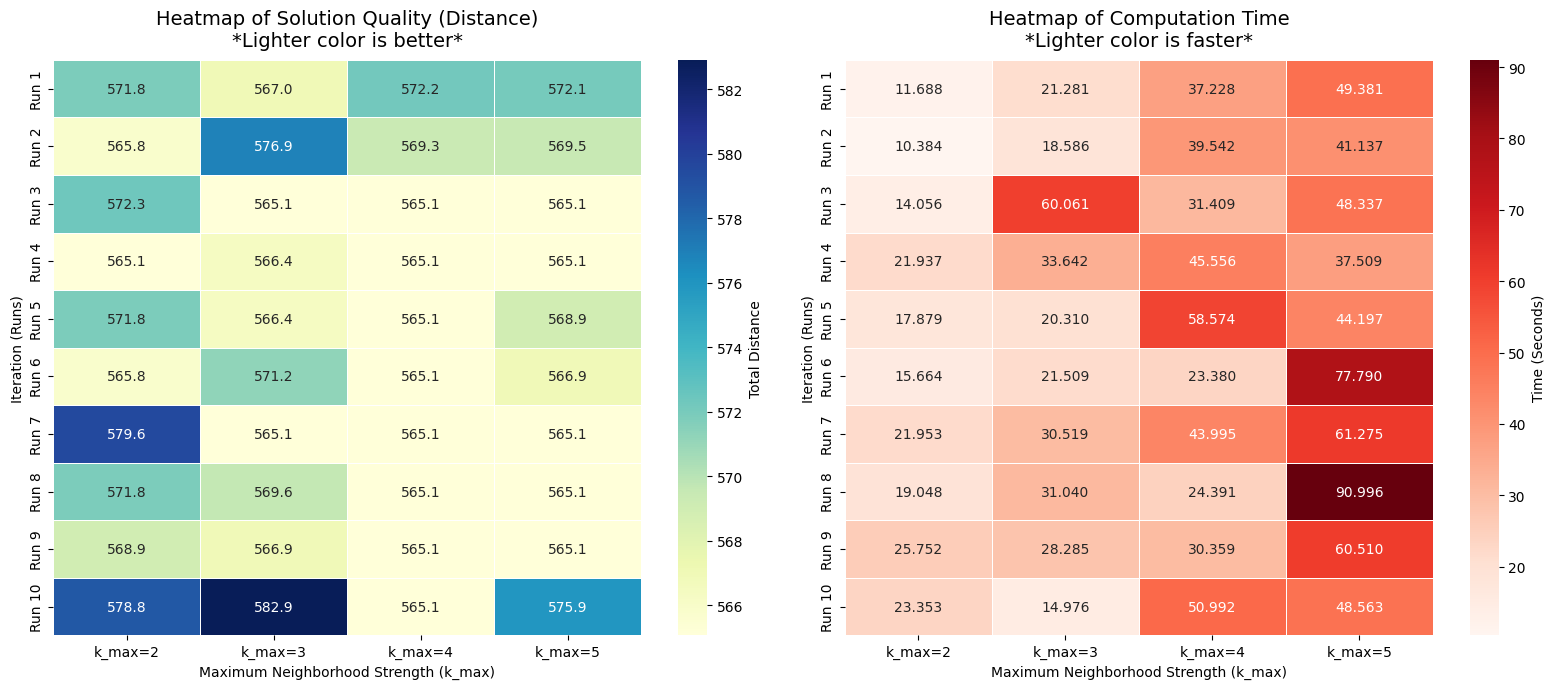


--- Statistical Analysis (One-way ANOVA) ---

[1] Solution Quality (Distance):
F-statistic: 2.35 | P-value: 8.8766e-02
Conclusion: Accept H0. No statistically significant difference in distance between k_max values.

[2] Computation Time (Seconds):
F-statistic: 17.07 | P-value: 4.6302e-07
Conclusion: Reject H0. The number of neighborhoods (k_max) SIGNIFICANTLY affects computation time.
Result: Higher k_max requires more time. 'k_max=2' is the fastest, while 'k_max=5' is the slowest.


In [3]:
import random
import math
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Configuration & Setup
# ==========================================
N_CITIES = 50
RUNS_PER_KMAX = 10
K_MAX_VALUES = [2, 3, 4, 5]
MAX_NO_IMPROVEMENT = 40  # Stopping condition: stop if no improvement after 40 iterations

# Generate 50 cities once so all tests run on the exact same map
np.random.seed(42)
random.seed(42)
cities = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N_CITIES)]

# Precompute distance matrix for ultra-fast calculation
dist_matrix = [[math.dist(cities[i], cities[j]) for j in range(N_CITIES)] for i in range(N_CITIES)]

def total_distance(tour):
    """ Calculate the total distance of the TSP tour """
    return sum(dist_matrix[tour[i - 1]][tour[i]] for i in range(N_CITIES))

# ==========================================
# 2. VNS Components
# ==========================================
def local_search_2opt(tour):
    """ Intensification: Standard 2-opt local search to find local minimum """
    current_tour = tour[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, N_CITIES - 1):
            for j in range(i + 1, N_CITIES):
                if j - i == 1:
                    continue # Skip adjacent edges

                # Perform the 2-opt edge swap
                new_tour = current_tour[:i] + current_tour[i:j][::-1] + current_tour[j:]

                if total_distance(new_tour) < total_distance(current_tour):
                    current_tour = new_tour
                    improved = True
                    break
            if improved:
                break
    return current_tour

def shake(tour, k):
    """ Diversification: Neighborhood structure N_k (Perform k random swaps) """
    new_tour = tour[:]
    # The higher the k, the more the route is disrupted
    for _ in range(k):
        idx1, idx2 = random.sample(range(N_CITIES), 2)
        new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
    return new_tour

def run_vns(k_max):
    """ Main Variable Neighborhood Search (VNS) Algorithm """
    # Reset random seed here so each run has a different initial path and random swaps
    random.seed()

    start_time = time.time()

    # Generate random initial solution and optimize it
    tour = list(range(N_CITIES))
    random.shuffle(tour)
    tour = local_search_2opt(tour)
    best_dist = total_distance(tour)

    no_improve_count = 0

    while no_improve_count < MAX_NO_IMPROVEMENT:
        k = 1
        while k <= k_max:
            # 1. Shake (Explore neighborhood N_k)
            shaken_tour = shake(tour, k)

            # 2. Local Search (Find local optimum in the new neighborhood)
            local_opt_tour = local_search_2opt(shaken_tour)
            local_dist = total_distance(local_opt_tour)

            # 3. Neighborhood Change Step
            if local_dist < best_dist:
                tour = local_opt_tour[:]
                best_dist = local_dist
                k = 1  # Reset k to 1 if improvement is found
                no_improve_count = 0
            else:
                k += 1 # Move to the next, larger neighborhood if no improvement

        no_improve_count += 1

    calc_time = time.time() - start_time
    return best_dist, calc_time

# ==========================================
# 3. Experiment Execution
# ==========================================
print("--- Starting VNS k_max Sensitivity Analysis ---")
results_dist = {f"k_max={k}": [] for k in K_MAX_VALUES}
results_time = {f"k_max={k}": [] for k in K_MAX_VALUES}

for k in K_MAX_VALUES:
    print(f"Running 10 tests for k_max = {k}...")
    for run in range(RUNS_PER_KMAX):
        dist, t = run_vns(k)
        results_dist[f"k_max={k}"].append(dist)
        results_time[f"k_max={k}"].append(t)

# Convert results to Pandas DataFrames
df_dist = pd.DataFrame(results_dist)
df_time = pd.DataFrame(results_time)
df_dist.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]
df_time.index = [f"Run {i+1}" for i in range(RUNS_PER_KMAX)]

# ==========================================
# 4. Visualization (Heatmaps)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap for Distance (Solution Quality) - YlGnBu Colormap
sns.heatmap(df_dist, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={'label': 'Total Distance'}, linewidths=.5)
axes[0].set_title("Heatmap of Solution Quality (Distance)\n*Lighter color is better*", fontsize=14, pad=10)
axes[0].set_ylabel("Iteration (Runs)")
axes[0].set_xlabel("Maximum Neighborhood Strength (k_max)")

# Heatmap for Time (Computation Time) - Reds Colormap
sns.heatmap(df_time, annot=True, fmt=".3f", cmap="Reds", ax=axes[1],
            cbar_kws={'label': 'Time (Seconds)'}, linewidths=.5)
axes[1].set_title("Heatmap of Computation Time\n*Lighter color is faster*", fontsize=14, pad=10)
axes[1].set_ylabel("Iteration (Runs)")
axes[1].set_xlabel("Maximum Neighborhood Strength (k_max)")

plt.tight_layout()
plt.show()

# ==========================================
# 5. Statistical Test (One-way ANOVA)
# ==========================================
print("\n" + "="*60)
print("--- Statistical Analysis (One-way ANOVA) ---")

# ANOVA for Distance
f_stat_dist, p_val_dist = stats.f_oneway(
    df_dist['k_max=2'], df_dist['k_max=3'], df_dist['k_max=4'], df_dist['k_max=5']
)
print(f"\n[1] Solution Quality (Distance):")
print(f"F-statistic: {f_stat_dist:.2f} | P-value: {p_val_dist:.4e}")
if p_val_dist < 0.05:
    best_k_dist = df_dist.mean().idxmin()
    print("Conclusion: Reject H0. The number of neighborhoods (k_max) SIGNIFICANTLY affects solution quality.")
    print(f"Result: '{best_k_dist}' provides the best average route distance.")
else:
    print("Conclusion: Accept H0. No statistically significant difference in distance between k_max values.")

# ANOVA for Time
f_stat_time, p_val_time = stats.f_oneway(
    df_time['k_max=2'], df_time['k_max=3'], df_time['k_max=4'], df_time['k_max=5']
)
print(f"\n[2] Computation Time (Seconds):")
print(f"F-statistic: {f_stat_time:.2f} | P-value: {p_val_time:.4e}")
if p_val_time < 0.05:
    fastest_k = df_time.mean().idxmin()
    slowest_k = df_time.mean().idxmax()
    print("Conclusion: Reject H0. The number of neighborhoods (k_max) SIGNIFICANTLY affects computation time.")
    print(f"Result: Higher k_max requires more time. '{fastest_k}' is the fastest, while '{slowest_k}' is the slowest.")
else:
    print("Conclusion: Accept H0. No statistically significant difference in computation time between k_max values.")

print("="*60)